In [1]:
import sys
sys.path.append('../src')
from llm_util import *

import torch
from torch import nn

In [2]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本

In [3]:
x_train

tensor([0.1100, 0.1903, 0.3260, 0.3441, 0.4341, 0.5253, 0.5737, 0.6163, 0.6219,
        0.8303, 1.0173, 1.0403, 1.0418, 1.0639, 1.1882, 1.1896, 1.3387, 1.3663,
        1.4164, 1.5666, 1.6827, 1.8961, 1.9196, 2.1024, 2.1337, 2.1440, 2.3235,
        2.3705, 2.4088, 2.5498, 2.7480, 2.8717, 2.9425, 3.0335, 3.1364, 3.2083,
        3.4178, 3.6770, 3.7331, 3.9046, 3.9134, 3.9924, 4.2216, 4.2294, 4.4187,
        4.4830, 4.6274, 4.7341, 4.7460, 4.9849])

In [5]:
def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本

In [6]:
x_test

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000,
        1.8000, 1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000,
        2.7000, 2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000,
        3.6000, 3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000,
        4.5000, 4.6000, 4.7000, 4.8000, 4.9000])

In [7]:
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数

In [8]:
n_test

50

In [10]:
def plot_kernel_reg(y_hat):
    plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    plt.plot(x_train, y_train, 'o', alpha=0.5);

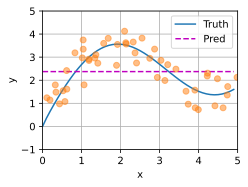

In [11]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

In [12]:
y_hat

tensor([2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747,
        2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747,
        2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747,
        2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747,
        2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747, 2.3747,
        2.3747, 2.3747, 2.3747, 2.3747, 2.3747])

In [13]:
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))

In [14]:
X_repeat

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
        [0.2000, 0.2000, 0.2000,  ..., 0.2000, 0.2000, 0.2000],
        ...,
        [4.7000, 4.7000, 4.7000,  ..., 4.7000, 4.7000, 4.7000],
        [4.8000, 4.8000, 4.8000,  ..., 4.8000, 4.8000, 4.8000],
        [4.9000, 4.9000, 4.9000,  ..., 4.9000, 4.9000, 4.9000]])

In [15]:
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)

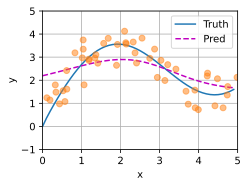

In [16]:
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

In [20]:
torch.set_printoptions(threshold=float('inf'))
print(attention_weights)

tensor([[6.7097e-02, 6.6293e-02, 6.4011e-02, 6.3624e-02, 6.1434e-02, 5.8805e-02,
         5.7260e-02, 5.5829e-02, 5.5633e-02, 4.7821e-02, 4.0234e-02, 3.9293e-02,
         3.9233e-02, 3.8332e-02, 3.3326e-02, 3.3268e-02, 2.7555e-02, 2.6544e-02,
         2.4758e-02, 1.9789e-02, 1.6386e-02, 1.1184e-02, 1.0694e-02, 7.4053e-03,
         6.9302e-03, 6.7794e-03, 4.5396e-03, 4.0658e-03, 3.7098e-03, 2.6157e-03,
         1.5473e-03, 1.0929e-03, 8.8952e-04, 6.7783e-04, 4.9350e-04, 3.9276e-04,
         1.9626e-04, 7.8252e-05, 6.3558e-05, 3.3022e-05, 3.1899e-05, 2.3340e-05,
         9.1084e-06, 8.8119e-06, 3.8856e-06, 2.9185e-06, 1.5125e-06, 9.1772e-07,
         8.6718e-07, 2.7127e-07],
        [6.2463e-02, 6.2212e-02, 6.0891e-02, 6.0633e-02, 5.9075e-02, 5.7065e-02,
         5.5836e-02, 5.4672e-02, 5.4511e-02, 4.7844e-02, 4.1013e-02, 4.0146e-02,
         4.0090e-02, 3.9256e-02, 3.4556e-02, 3.4502e-02, 2.9005e-02, 2.8019e-02,
         2.6264e-02, 2.1311e-02, 1.7853e-02, 1.2448e-02, 1.1931e-02, 8.4138

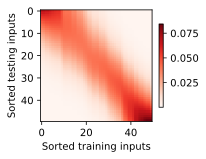

In [21]:
show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

In [22]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [23]:
X

tensor([[[1., 1., 1., 1.]],

        [[1., 1., 1., 1.]]])

In [25]:
weights = torch.ones((2, 10)) * 0.1

In [26]:
weights

tensor([[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000]])

In [27]:
values = torch.arange(20.0).reshape((2, 10))

In [28]:
values

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]])

In [29]:
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

In [30]:
weights.unsqueeze(1)

tensor([[[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
          0.1000, 0.1000]],

        [[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
          0.1000, 0.1000]]])

In [31]:
weights.unsqueeze(1).shape

torch.Size([2, 1, 10])

In [32]:
values.unsqueeze(-1).shape

torch.Size([2, 10, 1])

In [33]:
values.unsqueeze(-1)

tensor([[[ 0.],
         [ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.]],

        [[10.],
         [11.],
         [12.],
         [13.],
         [14.],
         [15.],
         [16.],
         [17.],
         [18.],
         [19.]]])

In [47]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))
        print(self.w)

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [48]:
net1 = NWKernelRegression()

Parameter containing:
tensor([0.1560], requires_grad=True)


In [37]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

In [43]:
keys.shape

torch.Size([50, 49])

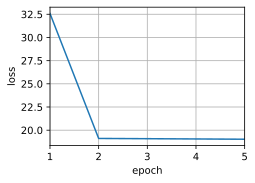

In [44]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

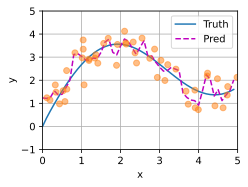

In [45]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

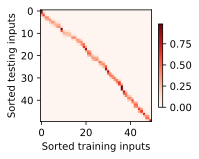

In [46]:
show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

In [49]:
net.parameters()

<generator object Module.parameters at 0x118c83ae0>

In [50]:
for name, param in net.named_parameters():
    print(f"--- {name} ---")
    print(param)

--- w ---
Parameter containing:
tensor([14.9648], requires_grad=True)
